# Convexity

## Convex Sets

A set $C \subseteq \mathbb{R}^n$ is **convex** if for any two points $x, y \in C$ and any $\lambda \in [0, 1]$:

$$
\lambda x + (1-\lambda)y \in C
$$

In words: the line segment between any two points in the set stays in the set. No "dents" or "holes."

**Examples:**

- Lines, line segments, half-spaces $\{x : a^Tx \leq b\}$
- Hyperplanes, balls, ellipsoids
- The probability simplex $\{x : x_i \geq 0, \sum x_i = 1\}$ — set of probability distributions
- Positive semidefinite matrices $\{X : X \succeq 0\}$ — covariance matrices form a convex set

**Why convex sets matter:** they're the feasible regions where optimization is tractable. Portfolio weight constraints ($w_i \geq 0$, $\sum w_i = 1$) form a convex set. Budget constraints, leverage constraints, position limits — all convex. This is why portfolio optimization is "well-behaved" mathematically.

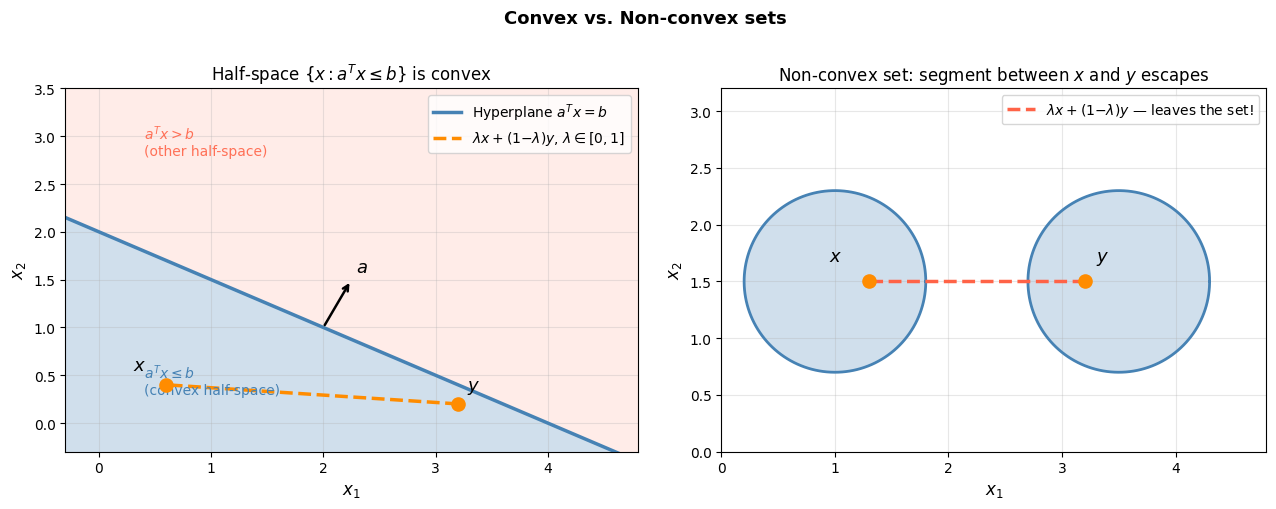

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── shared setup ──────────────────────────────────────────────────────────────
# Hyperplane: a^T x = b  →  x1 + 2*x2 = 4
a = np.array([1.0, 2.0])
b = 4.0
x1 = np.linspace(-0.5, 5.0, 400)
x2_hp = (b - a[0] * x1) / a[1]        # boundary line

# ── Left panel: half-space is convex ─────────────────────────────────────────
ax = axes[0]
ax.fill_between(x1, -1, x2_hp, alpha=0.25, color="steelblue")
ax.fill_between(x1, x2_hp, 4, alpha=0.12, color="tomato")
ax.plot(x1, x2_hp, color="steelblue", lw=2.5, label=r"Hyperplane $a^Tx = b$")

# Two points inside the half-space (a^Tx <= b)
P = np.array([0.6, 0.4])   # 0.6 + 0.8 = 1.4 ≤ 4
Q = np.array([3.2, 0.2])   # 3.2 + 0.4 = 3.6 ≤ 4

# Convex combination segment λP + (1−λ)Q stays inside
lam = np.linspace(0, 1, 200)
seg = np.outer(lam, P) + np.outer(1 - lam, Q)
ax.plot(seg[:, 0], seg[:, 1], color="darkorange", lw=2.5, ls="--",
        label=r"$\lambda x + (1{-}\lambda)y$, $\lambda \in [0,1]$")
ax.scatter([P[0], Q[0]], [P[1], Q[1]], s=90, color="darkorange", zorder=6)
ax.annotate(r"$x$", P, xytext=(P[0] - 0.3, P[1] + 0.15), fontsize=13)
ax.annotate(r"$y$", Q, xytext=(Q[0] + 0.08, Q[1] + 0.15), fontsize=13)

# Normal vector a pointing into the half-space complement
mid = np.array([2.0, (b - a[0] * 2.0) / a[1]])
a_hat = a / np.linalg.norm(a)
ax.annotate("", xy=mid + 0.55 * a_hat, xytext=mid,
            arrowprops=dict(arrowstyle="->", color="black", lw=1.8))
ax.text(*(mid + 0.65 * a_hat), r"$a$", fontsize=13)

ax.text(0.4, 2.8, r"$a^Tx > b$" + "\n(other half-space)",
        fontsize=10, color="tomato", alpha=0.9)
ax.text(0.4, 0.3, r"$a^Tx \leq b$" + "\n(convex half-space)",
        fontsize=10, color="steelblue")

ax.set_xlim(-0.3, 4.8); ax.set_ylim(-0.3, 3.5)
ax.set_xlabel("$x_1$", fontsize=12); ax.set_ylabel("$x_2$", fontsize=12)
ax.set_title(r"Half-space $\{x : a^Tx \leq b\}$ is convex", fontsize=12)
ax.legend(fontsize=10, loc="upper right"); ax.grid(True, alpha=0.3)

# ── Right panel: non-convex set for contrast ──────────────────────────────────
ax = axes[1]

# Non-convex set: union of two disjoint disks
theta = np.linspace(0, 2 * np.pi, 300)
c1, c2, r = np.array([1.0, 1.5]), np.array([3.5, 1.5]), 0.8

for cx, cy in [(c1[0], c1[1]), (c2[0], c2[1])]:
    circle = plt.Circle((cx, cy), r, color="steelblue", alpha=0.25)
    ax.add_patch(circle)
    ax.plot(cx + r * np.cos(theta), cy + r * np.sin(theta), color="steelblue", lw=2)

# Two points, one from each disk — segment leaves the set
P2 = c1 + 0.3 * np.array([1, 0])
Q2 = c2 - 0.3 * np.array([1, 0])
seg2 = np.outer(lam, P2) + np.outer(1 - lam, Q2)
ax.plot(seg2[:, 0], seg2[:, 1], color="tomato", lw=2.5, ls="--",
        label=r"$\lambda x + (1{-}\lambda)y$ — leaves the set!")
ax.scatter([P2[0], Q2[0]], [P2[1], Q2[1]], s=90, color="darkorange", zorder=6)
ax.annotate(r"$x$", P2, xytext=(P2[0] - 0.35, P2[1] + 0.18), fontsize=13)
ax.annotate(r"$y$", Q2, xytext=(Q2[0] + 0.1, Q2[1] + 0.18), fontsize=13)

ax.set_xlim(0, 4.8); ax.set_ylim(0, 3.2)
ax.set_xlabel("$x_1$", fontsize=12); ax.set_ylabel("$x_2$", fontsize=12)
ax.set_title("Non-convex set: segment between $x$ and $y$ escapes", fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3); ax.set_aspect("equal")

plt.suptitle("Convex vs. Non-convex sets", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## Convex Optimization

For a convex function over a convex set, any local minimum is a global minimum.

**Proof sketch.** Suppose $x^*$ is a local minimum but not global — so there exists $y$ with $f(y) < f(x^*)$. By convexity, for any $\lambda \in (0, 1)$:

$$
f(\lambda y + (1-\lambda)x^*) \leq \lambda f(y) + (1-\lambda)f(x^*) < f(x^*)
$$

By choosing $\lambda$ small enough, $\lambda y + (1-\lambda)x^*$ is arbitrarily close to $x^*$ — but has lower value. This contradicts $x^*$ being a local minimum.

**Three practical consequences:**

**1. Gradient descent converges to the global optimum.** No need to worry about getting stuck in local minima — there are none. Any descent direction leads to the unique answer. This is why convex problems are "solved" in a way that non-convex problems aren't.

**2. First-order optimality is sufficient.** For a convex function, $\nabla f(x^*) = 0$ is both necessary and sufficient for global optimality. You don't need to check second-order conditions or compare against other candidates — find a stationary point and you're done.

**3. Duality is tight.** Convex problems have well-behaved duals (Lagrangian and KKT conditions) that provide both bounds and solutions. The "primal-dual gap" is zero for convex problems under mild conditions — Slater's condition.

## Quadratic Programming (QP)

A QP optimizes a **quadratic** objective subject to **linear** constraints:

$$
\min_x \ \frac{1}{2}x^T Q x + c^T x \quad \text{subject to} \quad Ax \leq b, \ \ Ex = d
$$

The objective now has a quadratic term ($\frac{1}{2}x^TQx$) plus a linear term ($c^Tx$). Constraints stay linear, exactly like LP. So QP is one step up from LP: **curved objective, flat constraints.**

**The matrix $Q$ determines everything:**

- $Q \succeq 0$ (PSD) → convex QP → globally solvable, the nice case
- $Q \succ 0$ (PD) → strictly convex → unique global minimum
- $Q$ indefinite → non-convex QP → NP-hard, local minima everywhere

This is *why* the PSD-ness of covariance matrices matters so much — it's the property that makes portfolio optimization a convex QP rather than an intractable one.

**The geometry.** LP has flat hyperplane level sets (parallel lines). QP's objective has **ellipsoid** level sets when $Q$ is PD. So a QP is: find the lowest ellipsoid level set that still touches the feasible polytope.

The key consequence: the QP optimum is **not necessarily at a vertex**. A curved objective can make contact on a face, along an edge, or even in the interior (if the unconstrained minimum is already feasible). That's exactly why QP needs different algorithms than LP's simplex.

**One elegant fact — equality-constrained QP has a closed form.** With only equality constraints (no inequalities), the KKT conditions collapse to a single linear system:

$$
\begin{pmatrix} Q & E^T \\ E & 0 \end{pmatrix}\begin{pmatrix} x \\ \lambda \end{pmatrix} = \begin{pmatrix} -c \\ d \end{pmatrix}
$$

Solve this (it's just $Ax = b$ with a structured matrix) and you have the exact answer. So equality-constrained QP reduces to linear algebra — the very thing you spent two weeks on. Inequality constraints are what force it to become iterative (active-set or interior-point), because you don't know in advance which ones are binding.

**Solution methods:**

1. **Active-set = the KKT closed form applied iteratively** — guess which inequalities are active, solve the resulting equality-constrained QP (closed form above), check the guess, adjust. The QP analog of simplex. Good for small-to-medium problems.
2. **Interior-point** — cut through the interior, same as LP. Best for large problems. What Mosek and Axioma use for 500-1000 asset portfolios.

In [2]:
mu = np.array([0.3, 0.5, 0.2])
sigma = np.array([
    [0.10, 0.02, 0.04],
    [0.02, 0.08, 0.01],
    [0.04, 0.01, 0.12]
])
gamma = 2

## Mean Variance Optimization

**Mean-variance portfolio optimization** is convex:

- Objective: minimize $w^T \Sigma w$ (convex since $\Sigma \succeq 0$, covariance matrices are always PSD. Hessian is $2\Sigma$ which is PSD, so the function is convex)
- Subject to: $\mathbf{1}^T w = 1$, $w \geq 0$ (linear constraints, define convex set)
- Therefore solvable to the global optimum

**When convexity fails:**

- **Neural network training** — non-convex, local minima everywhere, why deep learning is hard
- **Combinatorial portfolio constraints** — integer constraints ( $w_i \in \{0, 1\}$) break convexity, makes problem NP-hard
- **Drawdown-constrained optimization** — non-convex due to path-dependent constraint
- **Real-world transaction costs with bid-ask spreads** — often non-convex due to fixed costs

**Variant 1:** Unconstrained mean variance optimization has a closed-form solution which is the direct inverse of the covariance matrix scaled by returns where $\gamma$ is the risk-aversion penalty:
$$\max_w \ \mu^Tw - \frac{\gamma}{2}w^T\Sigma w$$
Take the gradient with respoect to $w$ and set to zero:
$$\mu-\gamma \Sigma w = 0$$
Solve for $w$:
$$\boxed{w = \frac{1}{\gamma} \Sigma^{-1} \mu}$$

Sweep the risk-tolerance $\gamma$ from 0 to $\infty$ and you trace the entire efficient frontier — each $\gamma$ gives one point. Still a convex QP at every $\gamma$.

In [3]:
def unconstrained_mean_variance(mu, sigma, gamma):
    Sinv_mu   = np.linalg.solve(sigma, mu)      # Sigma^-1 mu
    w = Sinv_mu / gamma
    print(f"Target expected Returns: {mu @ w.T:.2%}")
    print(f"Target variance: {w @ sigma @ w.T:.2%}")
    print(f"Objective function value: {mu @ w.T - gamma * w @ sigma @ w.T / 2:.4f}")
    print(f"Optimal weights: {w.round(4)}")
    print(f"Gradient value: {(mu - gamma * sigma @ w).round(4)}")
unconstrained_mean_variance(mu, sigma, gamma)

Target expected Returns: 174.62%
Target variance: 87.31%
Objective function value: 0.8731
Optimal weights: [0.7911 2.8861 0.3291]
Gradient value: [ 0.  0. -0.]


**Variant 2:** Mean variance optimization with equailty constraint where weights sum to exactly 1.
$$\max_w \ \mu^Tw - \frac{\gamma}{2}w^T\Sigma w \quad \text{s.t.} \quad \mathbf{1}^Tw = 1$$
Set up the Lagrangian with the budget constraint:
$$\mathcal{L} = \mu^Tw - \frac{\gamma}{2}w^T\Sigma w - \lambda(\mathbf{1}^Tw - 1)$$
Take the gradient with respect to $w$ and set to zero:
$$\nabla_w \mathcal{L} = \mu - \gamma\Sigma w - \lambda\mathbf{1} = 0$$
Solve for $w$:
$$w = \frac{1}{\gamma}\Sigma^{-1}(\mu - \lambda\mathbf{1})$$
Now pin down $\lambda$ using the budget constraint $\mathbf{1}^Tw = 1$. Substitute:
$$\mathbf{1}^T \cdot \frac{1}{\gamma}\Sigma^{-1}(\mu - \lambda\mathbf{1}) = 1$$
$$\frac{1}{\gamma}\left(\mathbf{1}^T\Sigma^{-1}\mu - \lambda\,\mathbf{1}^T\Sigma^{-1}\mathbf{1}\right) = 1$$
Let $A = \mathbf{1}^T\Sigma^{-1}\mathbf{1}$ and $B = \mathbf{1}^T\Sigma^{-1}\mu$:
$$\lambda = \frac{B - \gamma}{A}​$$
Substitute back:
$$\boxed{w = \frac{1}{\gamma}\Sigma^{-1}\left(\mu - \frac{B - \gamma}{A}\mathbf{1}\right)}​$$

In [4]:
def mean_variance_with_budget_constraint(mu, sigma, gamma):
    n = len(mu)
    ones = np.ones(n)
    
    # closed form — pure equality-constrained QP
    Sinv_mu   = np.linalg.solve(sigma, mu)      # Sigma^-1 mu
    Sinv_one  = np.linalg.solve(sigma, ones)    # Sigma^-1 1
    A = ones @ Sinv_one
    B = ones @ Sinv_mu
    lam = (B - gamma) / A
    w = (Sinv_mu - lam * Sinv_one) / gamma
    print(f"Target expected Returns: {mu @ w.T:.2%}")
    print(f"Target variance: {w @ sigma @ w.T:.2%}")
    print(f"Objective function value: {mu @ w.T - gamma * w @ sigma @ w.T / 2:.4f}")
    print(f"Optimal weights: {w.round(4)}")
    print(f"Constraint value: {sum(w):.2%}")
    print(f"Shadow price: {lam:.4f}")
mean_variance_with_budget_constraint(mu, sigma, gamma)

Target expected Returns: 63.33%
Target variance: 17.78%
Objective function value: 0.4556
Optimal weights: [ 0.      1.4444 -0.4444]
Constraint value: 100.00%
Shadow price: 0.2778


**Variant 3:** Mean variance optimization with budget constraint and bounds.

In [5]:
def long_only_mean_variance(mu, sigma, gamma):
    n = len(mu)
    # with constraints — fall back to CVXPY
    w = cp.Variable(n)
    obj = cp.Maximize(mu @ w - (gamma/2) * cp.quad_form(w, cp.psd_wrap(sigma)))
    cons = [cp.sum(w) == 1, w >= 0]
    prob = cp.Problem(obj, cons)
    prob.solve(solver=cp.OSQP)
    if prob.status not in ("optimal", "optimal_inaccurate"):
        raise ValueError(f"solve failed: {prob.status}")
    print(f"Target expected Returns: {mu @ w.value.T:.2%}")
    print(f"Target variance: {w.value @ sigma @ w.value.T:.2%}")
    print(f"Objective function value: {mu @ w.value.T - gamma * w.value @ sigma @ w.value.T / 2:.4f}")
    print(f"Optimal weights: {w.value.round(4)}")
    print(f"Constraint value: {sum(w.value):.2%}")
long_only_mean_variance(mu, sigma, gamma)

Target expected Returns: 50.00%
Target variance: 8.00%
Objective function value: 0.4200
Optimal weights: [0. 1. 0.]
Constraint value: 100.00%


## Why Markowitz Fails in Practice

**Failure 1 — Estimation error, concentrated in $\mu$.** The optimizer needs two inputs, $\mu$ and $\Sigma$. Expected returns $\mu$ are *brutally* hard to estimate — a stock's mean return is buried under enormous volatility, and you need decades of data to pin it down even roughly. Small errors in $\mu$ produce wildly different optimal weights. Covariances are easier (more stable, estimable from higher-frequency data), but still noisy. Garbage in, garbage out — and $\mu$ is mostly garbage. Estimating a mean requires a long calendar span, while estimating a variance/covariance just requires frequent sampling — and you can always sample more frequently, but you can't make time pass faster.

**Failure 2 — Markowitz is an "error maximizer."** This is Michaud's famous critique, and it's the deep one. The optimizer systematically *loves* exactly the assets most likely to have favorable estimation errors: it overweights assets with high estimated return, low estimated variance, and low estimated correlation (an estimate is more likely to be extreme because of upward error than because the true value is genuinely that good). But those extreme estimates are precisely the ones most likely to be *wrong* in the optimistic direction. So the optimizer doesn't just tolerate estimation error — it actively seeks it out and concentrates the portfolio in it. The "optimal" portfolio is optimized partly on noise.

**Failure 3 — Extreme, unstable weights.** Unconstrained Markowitz produces huge long/short positions, corner solutions, and weights that swing violently with tiny input changes. Change one expected return by 0.1% and the whole portfolio reshuffles. The result is "optimal" but undiversified and untradeable — the opposite of what you wanted.

**Failure 4 — The $\Sigma^{-1}$ amplifies everything.** Every Markowitz formula runs through $\Sigma^{-1}$. When $\Sigma$ is **ill-conditioned** — a large condition number $\kappa(\Sigma) = \lambda_{max}/\lambda_{min}$, which happens whenever you have many assets relative to observations, or highly correlated assets — inverting it **amplifies estimation error by the condition number**. A near-singular $\Sigma$ (tiny smallest eigenvalue) means $\Sigma^{-1}$ has a huge largest eigenvalue, and that direction dominates the solution with pure noise. This is the exact ill-conditioning you saw in gradient descent and the GARCH Hessian — same mathematics, now wrecking your portfolio. The sample covariance matrix, when assets ≈ observations, is the textbook ill-conditioned matrix (this is the Marchenko-Pastur / RMT story).

| Failure | Fix |
| --- | --- |
| Noisy μ | Black-Litterman — blend with equilibrium prior |
| Avoid μ entirely | Risk parity, min-variance |
| Noisy / ill-conditioned Σ | Shrinkage (Ledoit-Wolf) |
| Bad eigenvalue structure | RMT eigenvalue cleaning |
| Extreme weights, instability | Constraints, robust optimization, resampling |